# Corporate Credit Rating — Classification Track
## Predicting Investment Grade vs. Non-Investment Grade (Binary Rating)

This notebook loads the preprocessed corporate financial dataset and builds, evaluates, visualizes, and compares classification models for credit risk classification.

## 1. Import Libraries

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score
)

# Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC

print('Libraries loaded successfully.')

## 2. Load Preprocessed Classification Dataset

Loading the preprocessed, encoded, and scaled training and test sets generated by `preprocessing.ipynb`.

In [ ]:
data_dir = '../data' if os.path.exists('../data') else 'data'

train_df = pd.read_csv(os.path.join(data_dir, 'train_classification_preprocessed.csv'))
test_df = pd.read_csv(os.path.join(data_dir, 'test_classification_preprocessed.csv'))

# Features and Targets
X_train_c = train_df.drop(columns=['Binary Rating'])
y_train_c = train_df['Binary Rating']

X_test_c = test_df.drop(columns=['Binary Rating'])
y_test_c = test_df['Binary Rating']

# Scaled feature arrays for model fitting
X_train_c_scaled = X_train_c.values
X_test_c_scaled = X_test_c.values

print(f'Loaded preprocessed classification data from {data_dir}:')
print(f'Training set: X = {X_train_c.shape}, y = {y_train_c.shape}')
print(f'Testing set:  X = {X_test_c.shape}, y = {y_test_c.shape}')

## 20. Classification Part A - 5 Models

In [37]:
clf_models = {}
clf_results = []

def add_clf_result(name, model, preds, probs):
    clf_models[name] = model

    acc = accuracy_score(y_test_c, preds)
    precision = precision_score(y_test_c, preds, average='weighted', zero_division=0)
    recall = recall_score(y_test_c, preds, average='weighted', zero_division=0)
    f1 = f1_score(y_test_c, preds, average='weighted')
    auc = roc_auc_score(y_test_c, probs)

    clf_results.append([
        name, acc, precision, recall, f1, auc
    ])

    print(name)
    print("Accuracy:", acc)
    print("Weighted Precision:", precision)
    print("Weighted Recall:", recall)
    print("Weighted F1:", f1)
    print("ROC-AUC:", auc)
    print()

### 20.1 Logistic Regression

In [38]:
log_clf = LogisticRegression(random_state=42, max_iter=1000)
log_clf.fit(X_train_c_scaled, y_train_c)
log_preds = log_clf.predict(X_test_c_scaled)
log_probs = log_clf.predict_proba(X_test_c_scaled)[:, 1]

add_clf_result("Logistic Regression", log_clf, log_preds, log_probs)

Logistic Regression
Accuracy: 0.8065342729019859
Weighted Precision: 0.8032268512343038
Weighted Recall: 0.8065342729019859
Weighted F1: 0.8015919040289522
ROC-AUC: 0.8414482983581602



### 20.2 K-Nearest Neighbors Classifier

In [39]:
knn_clf = KNeighborsClassifier(n_neighbors=5)
knn_clf.fit(X_train_c_scaled, y_train_c)
knn_preds = knn_clf.predict(X_test_c_scaled)
knn_probs = knn_clf.predict_proba(X_test_c_scaled)[:, 1]

add_clf_result("KNN Classifier", knn_clf, knn_preds, knn_probs)

KNN Classifier
Accuracy: 0.8731582319026265
Weighted Precision: 0.8720427616755305
Weighted Recall: 0.8731582319026265
Weighted F1: 0.8716027606820786
ROC-AUC: 0.9285618498785836



### 20.3 Gaussian Naive Bayes

In [40]:
nb_clf = GaussianNB()
nb_clf.fit(X_train_c_scaled, y_train_c)
nb_preds = nb_clf.predict(X_test_c_scaled)
nb_probs = nb_clf.predict_proba(X_test_c_scaled)[:, 1]

add_clf_result("Gaussian Naive Bayes", nb_clf, nb_preds, nb_probs)

Gaussian Naive Bayes
Accuracy: 0.7540038436899423
Weighted Precision: 0.7575349265720184
Weighted Recall: 0.7540038436899423
Weighted F1: 0.7554863449540788
ROC-AUC: 0.807516943930992



### 20.4 Decision Tree Classifier

In [41]:
dtc_clf = DecisionTreeClassifier(max_depth=5, random_state=42)
dtc_clf.fit(X_train_c_scaled, y_train_c)
dtc_preds = dtc_clf.predict(X_test_c_scaled)
dtc_probs = dtc_clf.predict_proba(X_test_c_scaled)[:, 1]

add_clf_result("Decision Tree Classifier", dtc_clf, dtc_preds, dtc_probs)

Decision Tree Classifier
Accuracy: 0.8097373478539398
Weighted Precision: 0.8070987619295181
Weighted Recall: 0.8097373478539398
Weighted F1: 0.8039054740928485
ROC-AUC: 0.8329391830669421



### 20.5 Support Vector Classifier

In [42]:
svc_clf = SVC(
    kernel='rbf',
    random_state=42,
    probability=True
)
svc_clf.fit(X_train_c_scaled, y_train_c)
svc_preds = svc_clf.predict(X_test_c_scaled)
svc_probs = svc_clf.predict_proba(X_test_c_scaled)[:, 1]

add_clf_result("Support Vector Classifier", svc_clf, svc_preds, svc_probs)

Support Vector Classifier
Accuracy: 0.8417680973734786
Weighted Precision: 0.8419366345847303
Weighted Recall: 0.8417680973734786
Weighted F1: 0.8366943785756009
ROC-AUC: 0.8887771374723642



## 20.6 Decision Tree Visualisation

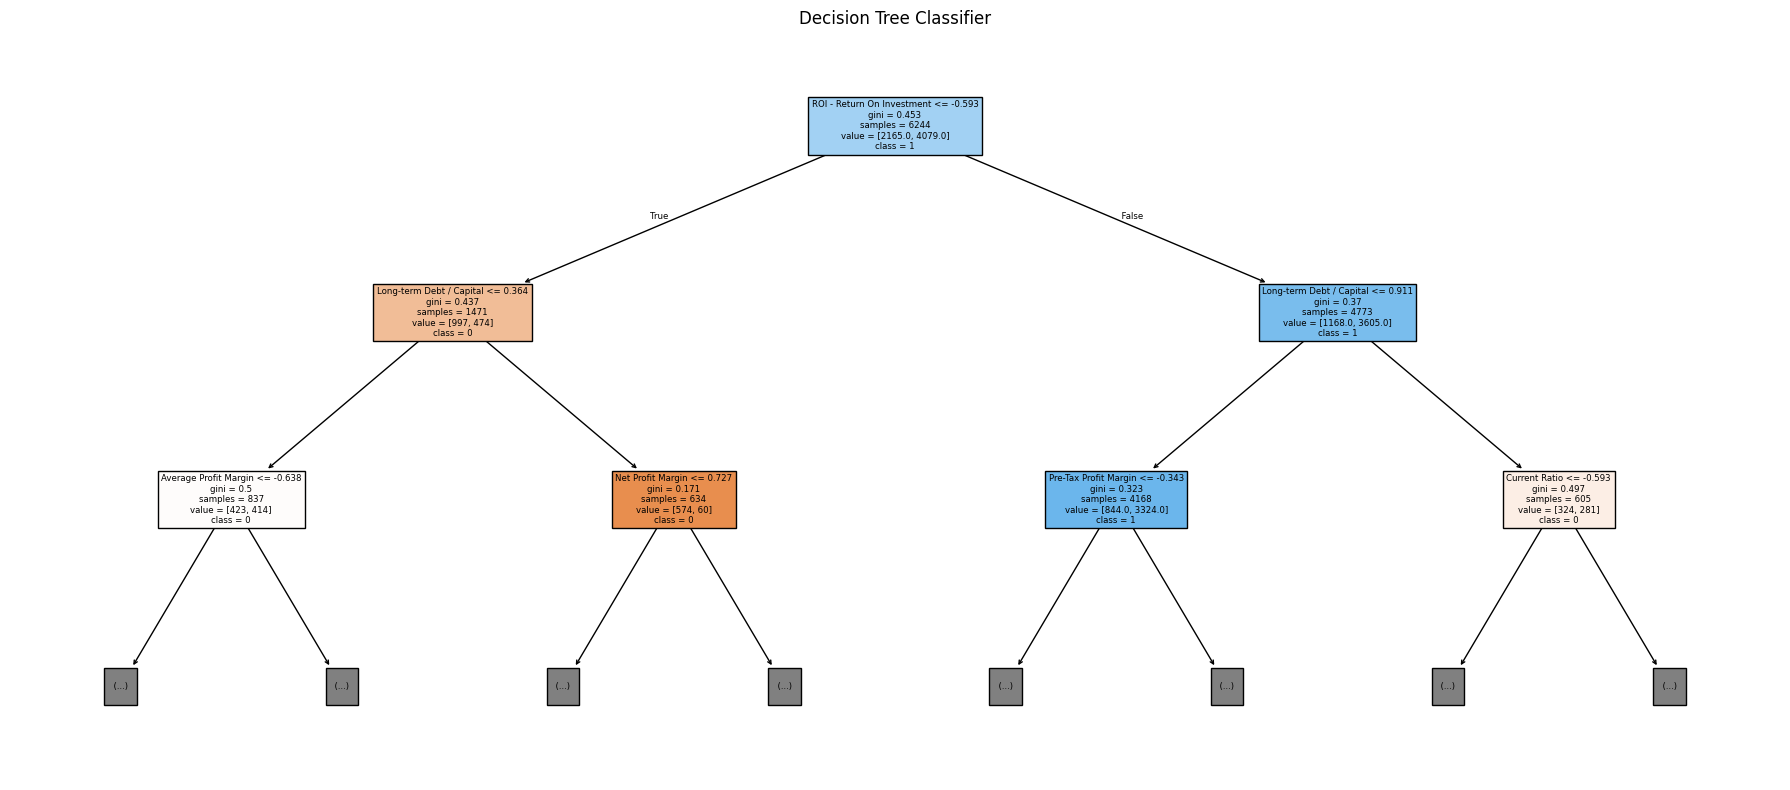

In [43]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 8))
plot_tree(
    dtc_clf,
    feature_names=X_train_c.columns,
    class_names=['0', '1'],
    filled=True,
    max_depth=2
)
plt.title('Decision Tree Classifier')
plt.tight_layout()
plt.show()


### Observation

The first levels of the tree show the main features used to separate the two rating classes. Deeper branches represent further decisions.


## 21. Classification Comparison

In [44]:
clf_results_df = pd.DataFrame(
    clf_results,
    columns=[
        'Model', 'Accuracy', 'Precision',
        'Recall', 'Weighted F1', 'ROC-AUC'
    ]
)

clf_results_df = clf_results_df.sort_values(
    by='Accuracy', ascending=False
).reset_index(drop=True)

clf_results_df

,Model,Accuracy,Precision,Recall,Weighted F1,ROC-AUC
0,KNN Classifier,0.873158,0.872043,0.873158,0.871603,0.928562
1,Support Vector Classifier,0.841768,0.841937,0.841768,0.836694,0.888777
2,Decision Tree Classifier,0.809737,0.807099,0.809737,0.803905,0.832939
3,Logistic Regression,0.806534,0.803227,0.806534,0.801592,0.841448
4,Gaussian Naive Bayes,0.754004,0.757535,0.754004,0.755486,0.807517


### Observation

The classification table compares the five Part-A algorithms. Accuracy shows overall correct predictions, while weighted F1 gives a better view when the classes are not perfectly balanced.

## 22. Confusion Matrices

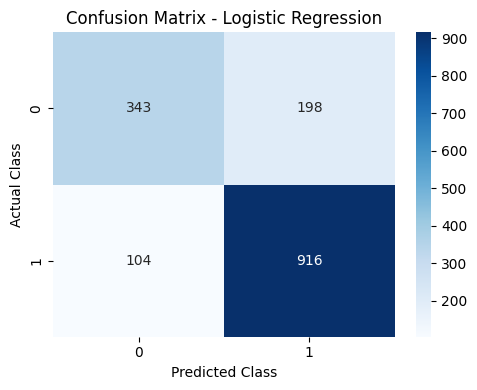

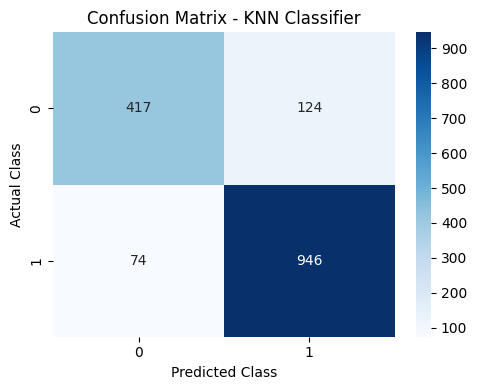

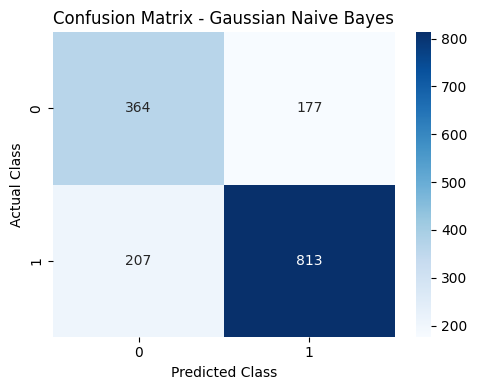

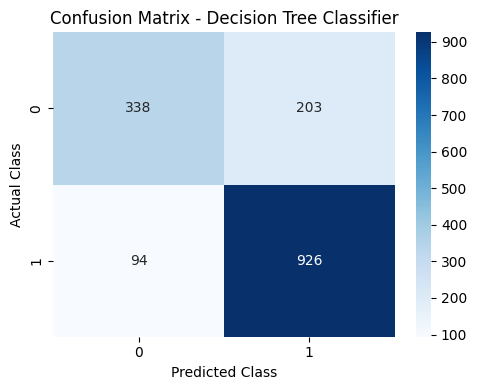

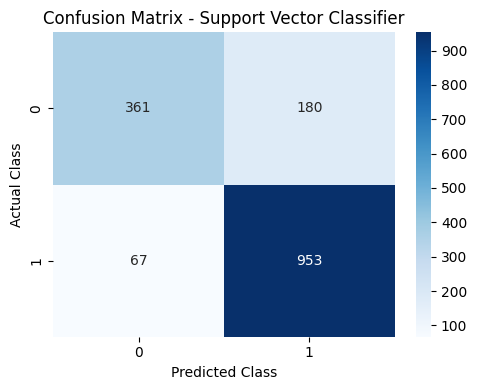

In [45]:
for name, model in clf_models.items():
    preds = model.predict(X_test_c_scaled)
    cm = confusion_matrix(y_test_c, preds)

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix - ' + name)
    plt.xlabel('Predicted Class')
    plt.ylabel('Actual Class')
    plt.tight_layout()
    plt.show()

### Observation

The diagonal values in each confusion matrix are correct predictions. Off-diagonal values show the classification errors between the two binary classes.

## 23. Review 1 Conclusion

### Summary

- The dataset was audited and cleaned.
- Exploratory analysis was performed on the financial features.
- A meaningful average profit-margin feature was created.
- Categorical data was encoded and numerical features were scaled using training data.
- All **10 required regression algorithms** were implemented and compared.
- Hyperparameter tuning was applied to two regression models.
- 5-fold cross-validation was performed for the two best regression models.
- Required regression visualisations were added.
- All **5 Review 1 classification algorithms** were implemented and evaluated.

The best model should be selected from the comparison tables based on the required metrics and the trade-off between performance and model complexity.

## Note on AI Assistance

AI assistance was used for code scaffolding and notebook organization. The dataset-specific analysis, observations, feature engineering choice, and final interpretation should be reviewed by the project team before submission.